In [5]:
# if on colab, run this call to do install
import sys
if 'google.colab' in sys.modules:
    !git clone --quiet --recursive https://github.com/fengzemin-Tim/image-matching-models.git
    %cd image-matching-models
    !pip install --progress-bar off --quiet -r requirements.txt
    !pip install --progress-bar off --quiet -e .


/content/image-matching-models/image-matching-models
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for image-matching-models (pyproject.toml) ... done


In [6]:
from matching import get_matcher, available_models
from matching.viz import *
from pathlib import Path
import torch
import warnings

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
ransac_kwargs = {'ransac_reproj_thresh':3,
                  'ransac_conf':0.95,
                  'ransac_iters':2000} # optional ransac params
matcher = get_matcher(['superpoint-lg'], device=device, **ransac_kwargs) #try an ensemble!

Using device: cpu


### Match Image Pair

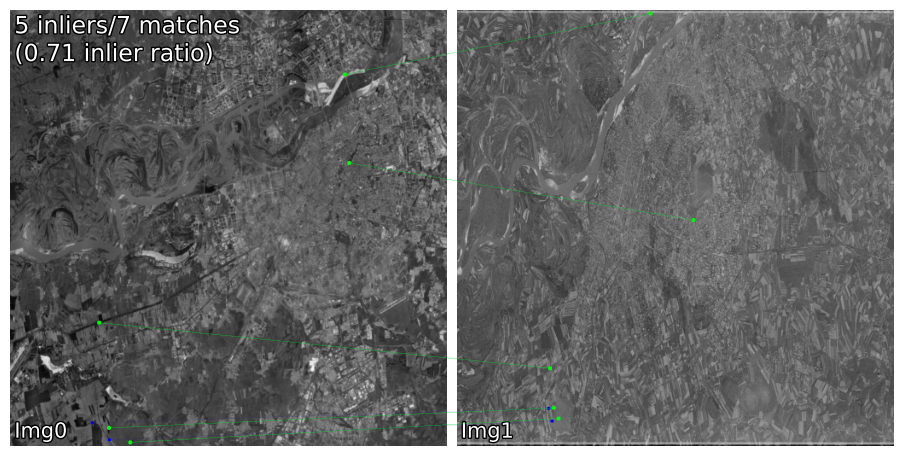

In [10]:
asset_dir = Path('assets/example_pairs')
pairs = list(asset_dir.iterdir())
image_size = 512

img0 = matcher.load_image('assets/123_gray_8bit.png', resize=image_size)
img1 = matcher.load_image('assets/image_10.png', resize=image_size)

result = matcher(img0, img1)
num_inliers, H, mkpts0, mkpts1 = result['num_inliers'], result['H'], result['inlier_kpts0'], result['inlier_kpts1']

plot_matches(img0, img1, result)

### Extract Kpts and Descriptors

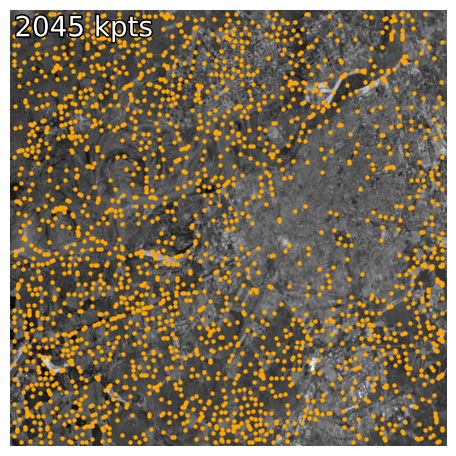

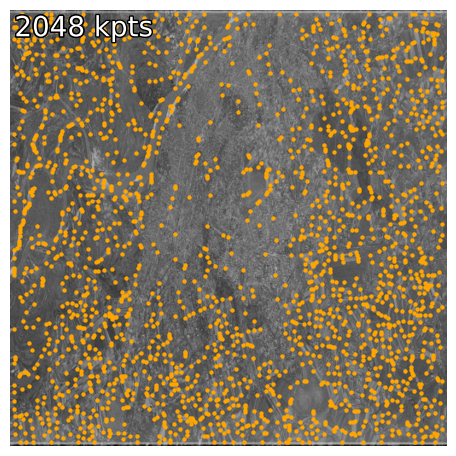

In [11]:
image_size = 512

# 加载两张固定图片
img0 = matcher.load_image('assets/123_gray_8bit.png', resize=image_size)
img1 = matcher.load_image('assets/image_10.png', resize=image_size)

# 分别提取关键点
result0 = matcher.extract(img0)
result1 = matcher.extract(img1)

# 分别画出关键点
plot_kpts(img0, result0)
plot_kpts(img1, result1)


### See all matchers on the same image pair

In [19]:
print(available_models)


['loftr', 'eloftr', 'se2loftr', 'xoftr', 'aspanformer', 'matchformer', 'sift-lg', 'superpoint-lg', 'disk-lg', 'aliked-lg', 'doghardnet-lg', 'roma', 'tiny-roma', 'dedode', 'steerers', 'affine-steerers', 'dedode-kornia', 'sift-nn', 'orb-nn', 'patch2pix', 'superglue', 'r2d2', 'd2net', 'duster', 'master', 'doghardnet-nn', 'xfeat', 'xfeat-star', 'xfeat-lg', 'xfeat-steerers-perm', 'xfeat-steerers-learned', 'xfeat-star-steerers-perm', 'xfeat-star-steerers-learned', 'dedode-lg', 'gim-dkm', 'gim-lg', 'omniglue', 'xfeat-subpx', 'xfeat-lg-subpx', 'dedode-subpx', 'splg-subpx', 'aliked-subpx', 'sift-sphereglue', 'superpoint-sphereglue', 'minima', 'minima-roma', 'minima-roma-tiny', 'minima-splg', 'minima-loftr']


In [20]:
available_models = ['roma', 'tiny-roma', 'minima-roma', 'minima-roma-tiny']


In [16]:
import matplotlib.pyplot as plt

In [ ]:
%%capture

image_size = 512
img0 = matcher.load_image('assets/123_gray_8bit.png', resize=image_size)
img1 = matcher.load_image('assets/image_10.png', resize=image_size)
num_per_row = 3
fig, axs = plt.subplots(int(np.ceil(len(available_models)/num_per_row)), 2*num_per_row, figsize=(12, 20))
flat_axs = axs.flatten()

for idx, model in enumerate(available_models):
    idx = idx * 2
    ax0, ax1 = flat_axs[idx], flat_axs[idx+1]

    try:
        matcher = get_matcher(model, device=device)
        result = matcher(img0, img1)
        num_inliers, H, mkpts0, mkpts1 = result['num_inliers'], result['H'], result['inlier_kpts0'], result['inlier_kpts1']

        ax0.imshow(tensor_to_image(img0))
        ax1.imshow(tensor_to_image(img1))
        _ = viz2d.plot_matches(mkpts0, mkpts1, color='lime', lw=0.1, ps=1, axes=[ax0, ax1])
        ax0.text(image_size/2, -10, f'{model}: {len(mkpts1)} matches')

    except Exception as e:
        blank_img = np.zeros_like(tensor_to_image(img0))
        ax0.imshow(blank_img)
        ax1.imshow(blank_img)
        ax0.text(image_size/2, -10, f'{model}: Error')
        print(f'Error with {model}: {e}')

for ax in flat_axs:
    ax.axis('off')

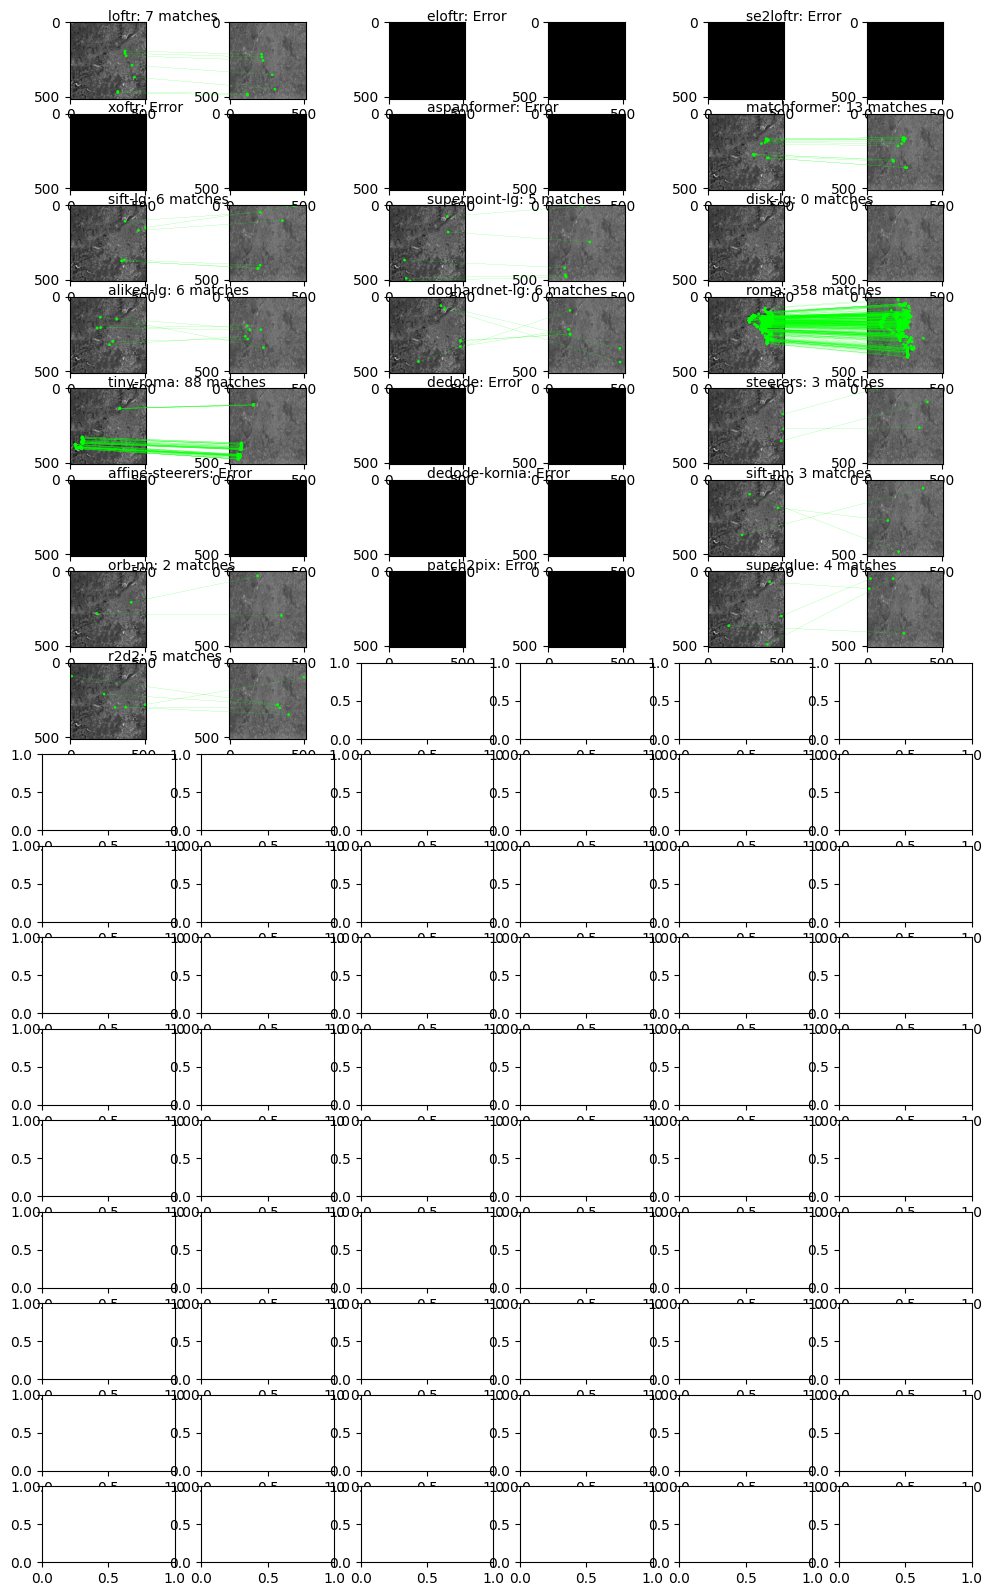

In [18]:
fig